In [530]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import importlib
import models.cox_model
import data.data_processor

from data.data_processor import DataProcessor
from data.splitter import SurvivalSplitter
from models.cox_model import CoxModel
from metrics.ibs import IBSMetric
from metrics.ibs_remain import IBSRemainMetric
from metrics.auprc import AUPRCMetric
from pipeline.evaluator import SurvivalEvaluator
from survivors.constants import get_y

In [531]:
df = pd.read_csv('data/individual_custody_timeline_rfm.csv')
print(df.columns)

Index(['name', 'age', 'sex', 'race', 'c_charge_degree', 'c_charge_desc',
       'in_custody', 'out_custody', 'custody_num', 'time_to_last_custody',
       'time_since_last_arrest', 'time_to_future_arrest', 'event',
       'event_of_future_arrest', 'curr_dur_custody', 'sum_dur_custody',
       'average_dur_custody', 'all_future_arrest_times', 'all_future_events'],
      dtype='object')


In [ ]:
importlib.reload(data.data_processor)

processor = DataProcessor("data/individual_custody_timeline_rfm.csv")
cox_df = processor.load_and_prepare()
cox_df = pd.get_dummies(
    cox_df,
    columns=["sex", "race"],
    drop_first=True
)
cox_df.head()
print(cox_df.columns)

Index(['name', 'episode_col', 'entry', 'dur', 'event', 'age',
       'time_since_last_arrest', 'average_dur_custody', 'curr_dur_custody',
       'sex_Male', 'race_Asian', 'race_Caucasian', 'race_Hispanic',
       'race_Native American', 'race_Other', 'c_charge_degree_(F1)',
       'c_charge_degree_(F2)', 'c_charge_degree_(F3)', 'c_charge_degree_(F5)',
       'c_charge_degree_(F6)', 'c_charge_degree_(F7)', 'c_charge_degree_(M1)',
       'c_charge_degree_(M2)', 'c_charge_degree_(MO3)',
       'c_charge_degree_(NI0)'],
      dtype='object')


In [533]:
splitter = SurvivalSplitter(test_size=0.2)
train_df, test_df = splitter.split_by_individual(cox_df)
train_df = train_df.drop(columns=["curr_dur_custody"])
test_df = test_df.drop(columns=["curr_dur_custody"])

print("Train individuals:", train_df["name"].nunique())
print("Test individuals:", test_df["name"].nunique())

Train individuals: 3382
Test individuals: 845


In [534]:
train_df["time"] = train_df["entry"] + train_df["dur"]
test_df["time"] = test_df["entry"] + test_df["dur"]

train_cens = train_df["event"].astype(bool)
test_cens = test_df["event"].astype(bool)

survival_train = get_y(
    cens=train_cens,
    time=train_df["time"],
    competing=False
)

survival_test = get_y(
    cens=test_cens,
    time=test_df["time"],
    competing=False
)


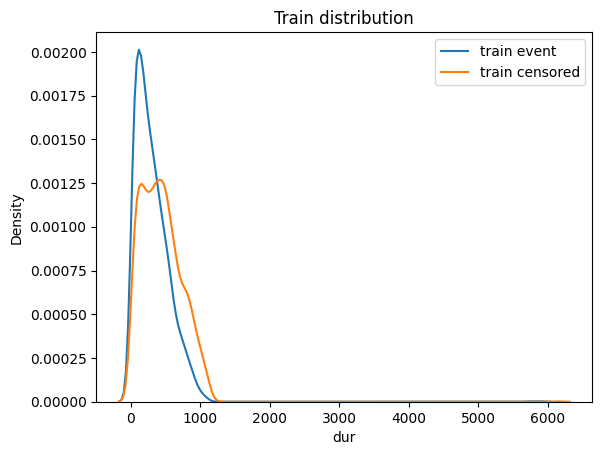

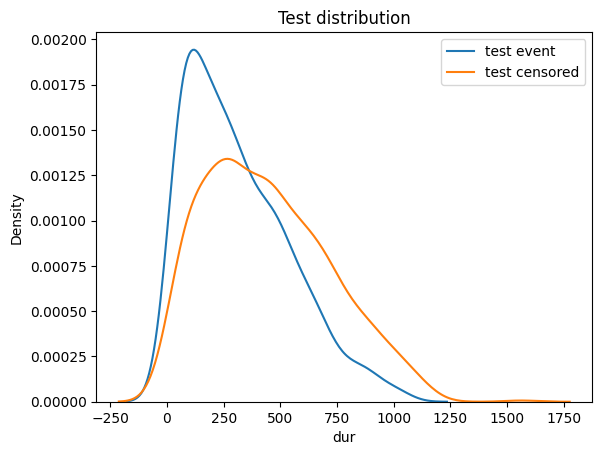

Train events: event
0    3382
1    2767
Name: count, dtype: int64
Test events: event
0    845
1    778
Name: count, dtype: int64


In [535]:
plt.figure()
sns.kdeplot(train_df[train_df["event"]==1]["dur"], label="train event")
sns.kdeplot(train_df[train_df["event"]==0]["dur"], label="train censored")
plt.legend()
plt.title("Train distribution")
plt.show()

plt.figure()
sns.kdeplot(test_df[test_df["event"]==1]["dur"], label="test event")
sns.kdeplot(test_df[test_df["event"]==0]["dur"], label="test censored")
plt.legend()
plt.title("Test distribution")
plt.show()

print("Train events:", train_df["event"].value_counts())
print("Test events:", test_df["event"].value_counts())


In [536]:
importlib.reload(models.cox_model)

print(train_df.columns)

features = [c for c in train_df.columns 
            if c not in ["name", "entry", "time", "event", "dur", "episode_col"]]
print(features)

cols_for_model = ["name", "entry", "time", "event"] + features
train_model_df = train_df[cols_for_model].copy()


model = CoxModel(features=features)
model.fit(train_model_df)

Index(['name', 'episode_col', 'entry', 'dur', 'event', 'age',
       'time_since_last_arrest', 'average_dur_custody', 'sex_Male',
       'race_Asian', 'race_Caucasian', 'race_Hispanic', 'race_Native American',
       'race_Other', 'c_charge_degree_(F1)', 'c_charge_degree_(F2)',
       'c_charge_degree_(F3)', 'c_charge_degree_(F5)', 'c_charge_degree_(F6)',
       'c_charge_degree_(F7)', 'c_charge_degree_(M1)', 'c_charge_degree_(M2)',
       'c_charge_degree_(MO3)', 'c_charge_degree_(NI0)', 'time'],
      dtype='object')
['age', 'time_since_last_arrest', 'average_dur_custody', 'sex_Male', 'race_Asian', 'race_Caucasian', 'race_Hispanic', 'race_Native American', 'race_Other', 'c_charge_degree_(F1)', 'c_charge_degree_(F2)', 'c_charge_degree_(F3)', 'c_charge_degree_(F5)', 'c_charge_degree_(F6)', 'c_charge_degree_(F7)', 'c_charge_degree_(M1)', 'c_charge_degree_(M2)', 'c_charge_degree_(MO3)', 'c_charge_degree_(NI0)']


model,lifelines.CoxPHFitter
duration col,'time'
event col,'event'
entry col,'entry'
cluster col,'name'
robust variance,True
baseline estimation,breslow
number of observations,6149
number of events observed,2767
partial log-likelihood,-20397.86
time fit was run,2026-02-18 12:02:31 UTC


<class 'lifelines.fitters.coxph_fitter.CoxPHFitter'>


In [537]:
#times = np.linspace(0, train_df["dur"].max(), 200)
horizon = np.quantile(train_df["dur"], 0.95)
times = np.linspace(0, horizon, 200)

test_features = test_df.drop(columns=["time", "event"])
predictions = model.predict_survival(test_features, times)
#predictions = model.predict_survival(test_df, times)
estimate = predictions.values

print("Estimate shape:", estimate.shape)
print("Test size:", len(test_df))

ibs_metric = IBSMetric()
mean_ibs, ibs_by_time = ibs_metric.compute(
    survival_train,
    survival_test,
    estimate,
    times
)

mean_ibs

Estimate shape: (1623, 200)
Test size: 1623


np.float64(0.18014534535013946)

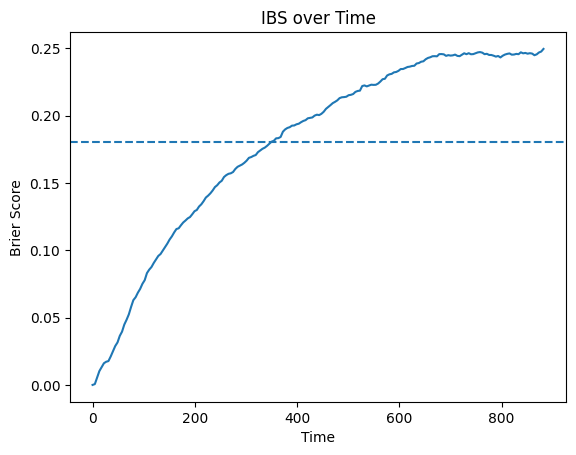

In [538]:
plt.plot(times, ibs_by_time)
plt.axhline(y=mean_ibs, linestyle="--")
plt.title("IBS over Time")
plt.xlabel("Time")
plt.ylabel("Brier Score")
plt.show()